In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv(r"C:\Users\heman\Downloads\HBO_Content.csv")

In [17]:
df

,index,title,type,year,rating,imdb_score,rotten_score,decade,imdb_bucket,genres_Action_Adventure,...,platforms_hbo_max,platforms_hoopla,platforms_hulu_plus,platforms_kanopy,platforms_netflix,platforms_shoutfactorytv,platforms_sundancenow,platforms_syfy_tveverywhere,platforms_tlc_go,platforms_viceland_tve
0,0,Game of Thrones,TV,2011,R/TV-MA,9.3,89.0,2010-2019,9.01-9.50,1,...,1,0,0,0,0,0,0,0,0,0
1,1,Fight Club,NaN,1999,R/TV-MA,8.8,79.0,1990-1999,8.51-9.00,0,...,1,0,0,0,0,0,0,0,0,0
2,2,Alien,NaN,1979,R/TV-MA,8.4,94.0,1970-1979,8.01-8.50,0,...,1,0,0,0,0,0,0,0,0,0
3,3,Chernobyl,TV,2019,R/TV-MA,9.4,96.0,2010-2019,9.01-9.50,0,...,1,0,0,0,0,0,0,0,0,0
4,4,Die Hard,NaN,1988,R/TV-MA,8.2,93.0,1980-1989,8.01-8.50,1,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1381,1381,Natacha,NaN,2019,NaN,NaN,NaN,2010-2019,NaN,0,...,1,0,0,0,0,0,0,0,0,0
1382,1382,Destino Deporte,TV,2013,NaN,NaN,NaN,2010-2019,NaN,0,...,0,0,0,0,0,0,0,0,0,0
1383,1383,Hijos del Carnaval,TV,2008,NaN,NaN,NaN,2000-2009,NaN,0,...,1,0,0,0,0,0,0,0,0,0
1384,1384,Mandrake Telefilm: Part 1,NaN,2013,NaN,NaN,NaN,2010-2019,NaN,0,...,1,0,0,0,0,0,0,0,0,0


In [53]:
df = df.drop_duplicates()
print(df)

      index                      title           type  year     rating  \
0         0            Game of Thrones             TV  2011    R/TV-MA   
1         1                 Fight Club  Movie/Unknown  1999    R/TV-MA   
2         2                      Alien  Movie/Unknown  1979    R/TV-MA   
3         3                  Chernobyl             TV  2019    R/TV-MA   
4         4                   Die Hard  Movie/Unknown  1988    R/TV-MA   
...     ...                        ...            ...   ...        ...   
1381   1381                    Natacha  Movie/Unknown  2019  Not Rated   
1382   1382            Destino Deporte             TV  2013  Not Rated   
1383   1383         Hijos del Carnaval             TV  2008  Not Rated   
1384   1384  Mandrake Telefilm: Part 1  Movie/Unknown  2013  Not Rated   
1385   1385    Orlando Leyba: Adorable  Movie/Unknown  2018  Not Rated   

      imdb_score  rotten_score     decade imdb_bucket  \
0       9.300000          89.0  2010-2019   9.01-9.50 

In [57]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1386 entries, 0 to 1385
Data columns (total 53 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   index                        1386 non-null   int64  
 1   title                        1386 non-null   object 
 2   type                         1386 non-null   object 
 3   year                         1386 non-null   int64  
 4   rating                       1386 non-null   object 
 5   imdb_score                   1386 non-null   float64
 6   rotten_score                 798 non-null    float64
 7   decade                       1386 non-null   object 
 8   imdb_bucket                  1326 non-null   object 
 9   genres_Action_Adventure      1386 non-null   int64  
 10  genres_Animation             1386 non-null   int64  
 11  genres_Biography             1386 non-null   int64  
 12  genres_Children              1386 non-null   int64  
 13  genres_Comedy     

In [21]:
print("Columns in dataset:", df.columns.tolist())
print(df.head())

Columns in dataset: ['index', 'title', 'type', 'year', 'rating', 'imdb_score', 'rotten_score', 'decade', 'imdb_bucket', 'genres_Action_Adventure', 'genres_Animation', 'genres_Biography', 'genres_Children', 'genres_Comedy', 'genres_Crime', 'genres_Cult', 'genres_Documentary', 'genres_Drama', 'genres_Family', 'genres_Fantasy', 'genres_Food', 'genres_Game Show', 'genres_History', 'genres_Horror', 'genres_Independent', 'genres_LGBTQ', 'genres_Musical', 'genres_Mystery', 'genres_Reality', 'genres_Romance', 'genres_Science_Fiction', 'genres_Sport', 'genres_Stand_up_Talk', 'genres_Thriller', 'genres_Travel', 'platforms_acorntv', 'platforms_amazon_prime', 'platforms_cinemax', 'platforms_epix', 'platforms_fandor', 'platforms_free', 'platforms_fubo_tv', 'platforms_hbo', 'platforms_hbo_max', 'platforms_hoopla', 'platforms_hulu_plus', 'platforms_kanopy', 'platforms_netflix', 'platforms_shoutfactorytv', 'platforms_sundancenow', 'platforms_syfy_tveverywhere', 'platforms_tlc_go', 'platforms_viceland_

In [43]:
df['type'] = df['type'].fillna("Movie/Unknown")
df['rating'] = df['rating'].fillna("Not Rated") 
df['imdb_score'] = df['imdb_score'].fillna(df['imdb_score'].mean())
df = df[df['year'].between(1900, 2025)]
type_counts = df['type'].value_counts()
print("Shape after cleaning:", df.shape)

Shape after cleaning: (1386, 53)


In [25]:
titles_per_decade = df['decade'].value_counts().sort_index()
print("\nTitles per Decade:\n", titles_per_decade)


Titles per Decade:
 decade
1960-1969      9
1970-1979     18
1980-1989     66
1990-1999    186
2000-2009    345
2010-2019    729
2020-2029     33
Name: count, dtype: int64


In [33]:
avg_score_type = df.groupby("type")["imdb_score"].mean()
print("\nAverage IMDb Score by Type:\n", avg_score_type)


Average IMDb Score by Type:
 type
Movie/Unknown    6.658958
TV               7.473346
Name: imdb_score, dtype: float64


In [35]:
genre_cols = [col for col in df.columns if col.startswith("genres_")]
genre_counts = df[genre_cols].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Genres:\n", genre_counts)


Top 10 Genres:
 genres_Drama               619
genres_Comedy              483
genres_Documentary         413
genres_Action_Adventure    248
genres_Thriller            221
genres_Romance             219
genres_Mystery             213
genres_Crime               188
genres_Family              146
genres_Biography           114
dtype: int64


In [37]:
platform_cols = [col for col in df.columns if col.startswith("platforms_")]
platform_counts = df[platform_cols].sum().sort_values(ascending=False)
print("\nPlatform Distribution:\n", platform_counts)


Platform Distribution:
 platforms_hbo                  1386
platforms_hbo_max              1201
platforms_hoopla                 53
platforms_amazon_prime           40
platforms_free                   28
platforms_hulu_plus              13
platforms_kanopy                  9
platforms_cinemax                 7
platforms_shoutfactorytv          6
platforms_epix                    2
platforms_tlc_go                  1
platforms_syfy_tveverywhere       1
platforms_sundancenow             1
platforms_acorntv                 1
platforms_netflix                 1
platforms_fubo_tv                 1
platforms_fandor                  1
platforms_viceland_tve            1
dtype: int64


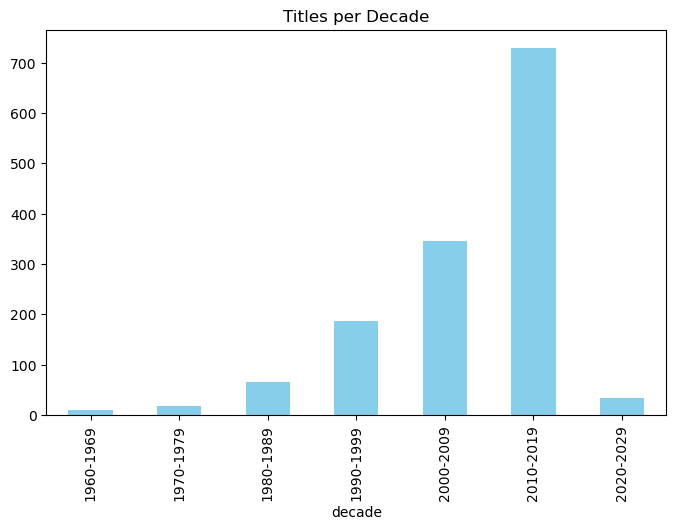

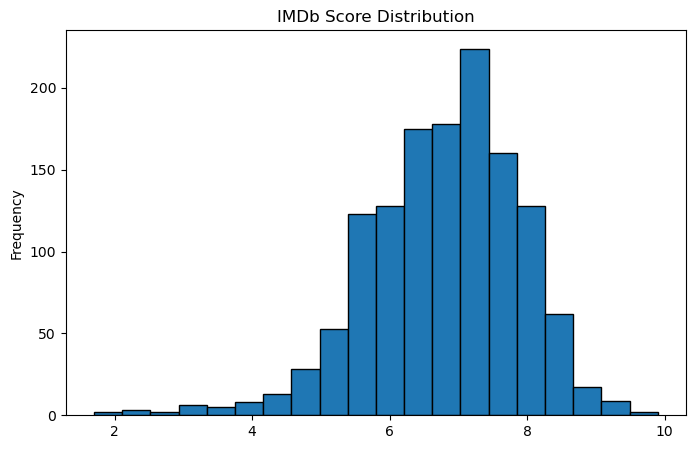

In [50]:
titles_per_decade.plot(kind="bar", figsize=(8,5), color="skyblue", title="Titles per Decade")
plt.show()
df['imdb_score'].plot(kind="hist", bins=20, edgecolor="black", figsize=(8,5), title="IMDb Score Distribution")
plt.show()

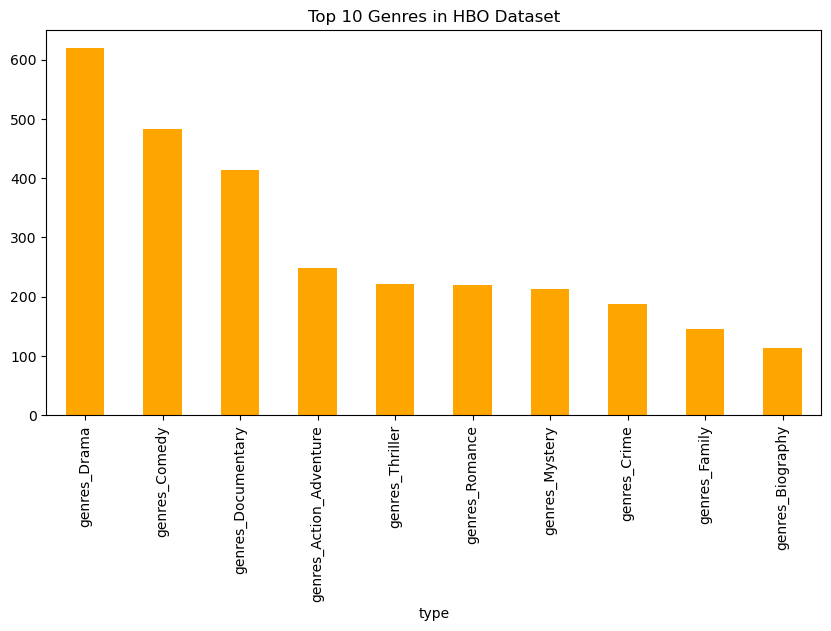

In [39]:
avg_score_type.plot(kind="bar", color="lightgreen", figsize=(6,4), title="Average IMDb Score by Type")
genre_counts.plot(kind="bar", color="orange", figsize=(10,5), title="Top 10 Genres in HBO Dataset")
plt.show()
plt.show()

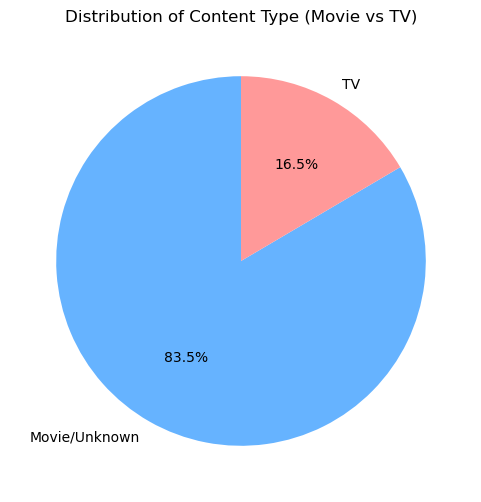

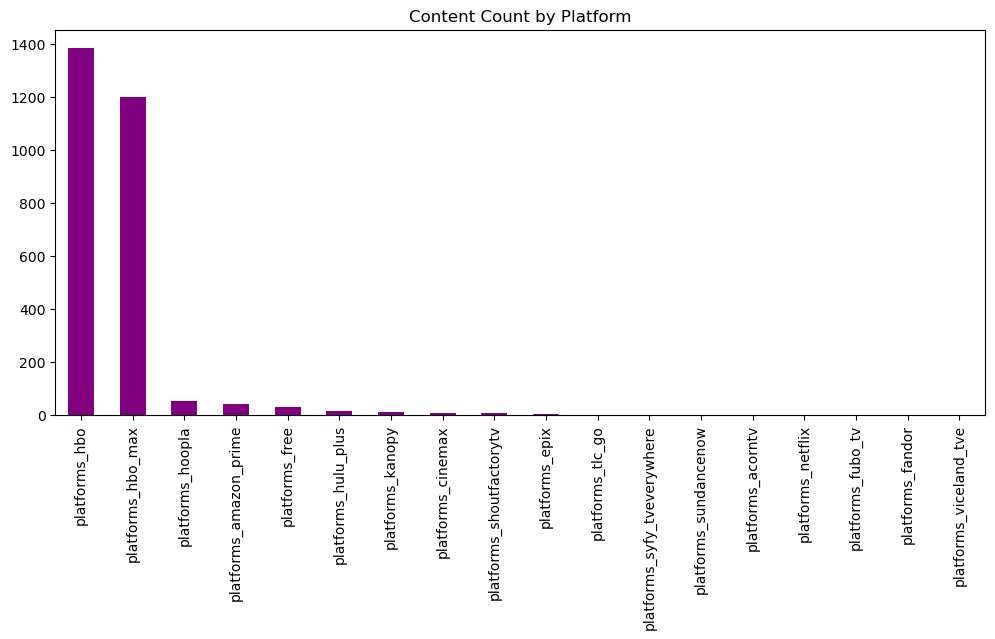

In [49]:
plt.figure(figsize=(6,6))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title("Distribution of Content Type (Movie vs TV)")
plt.show()
platform_counts.plot(kind="bar", color="purple", figsize=(12,5), title="Content Count by Platform")
plt.show()

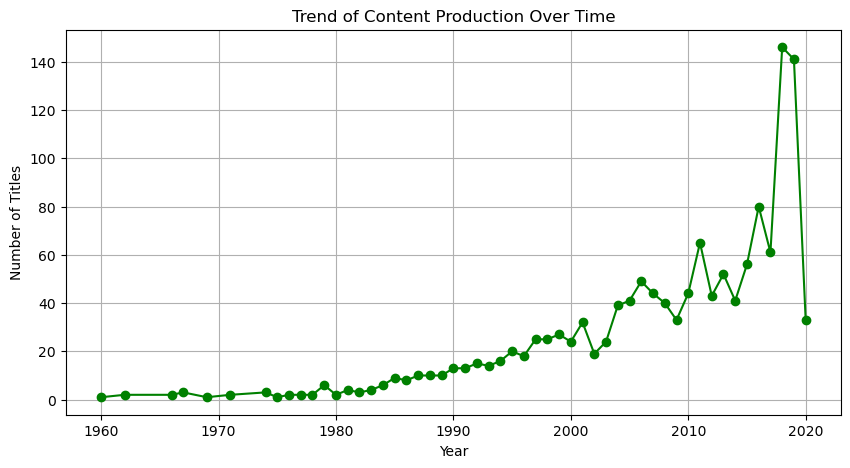

In [59]:
yearly_trend = df.groupby('year').size()
plt.figure(figsize=(10,5))
yearly_trend.plot(kind='line', marker='o', color='green')
plt.title("Trend of Content Production Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()

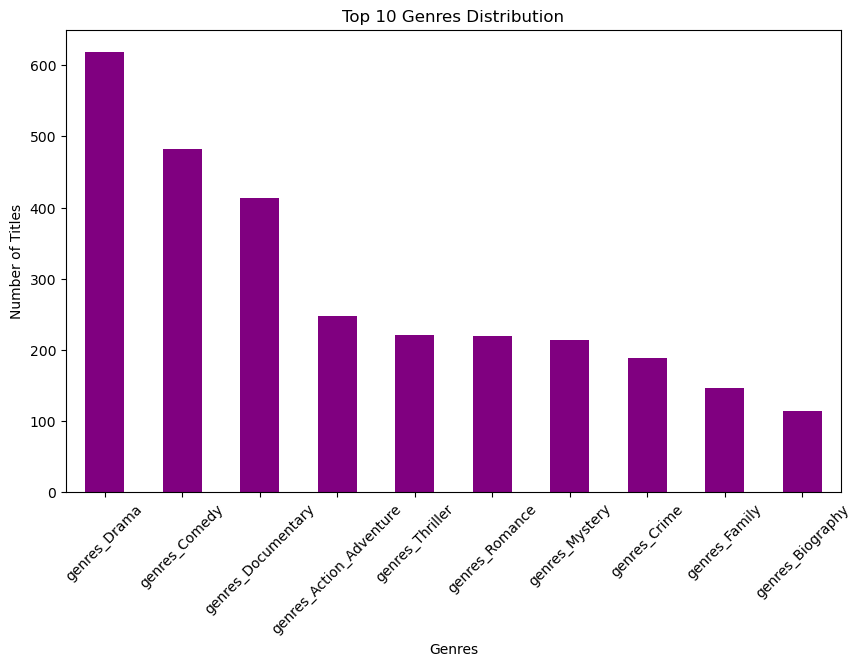

In [61]:
genre_cols = [col for col in df.columns if col.startswith("genres_")]
genre_sum = df[genre_cols].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
genre_sum.plot(kind="bar", color="purple")
plt.title("Top 10 Genres Distribution")
plt.xlabel("Genres")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()